In [7]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
sys.path.extend([str(Path.cwd().parents[2]), str(Path.cwd().parent)])

from im_net import datamanager, plotting
import datareader

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plot_path = "../figures/appendix/hebb_scaling"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

pid_palette = ['#ea535a', '#0066ac', '#9a26c8ff', '#eebbeeff', '#cadce0ff']

alpha_h = 0.14

## Data Loading

Redundancy $\Pi_\mathrm{red}$ as a function of memory load $\alpha$, for
Hebbian-initialized networks (no infomorphic training), across several
network sizes $N$.

In [3]:
# TODO: set path to Hebb-scaling experiment folder (full run, all N)
path = ''

dm = datamanager.DataManager(path, mode='analysis', add_run_properties=True)
datareader.sort_dm(dm, 'model.init.external_scale')
n_seeds = len(dm.sel['params.seed'].unique())

# Fix external_scale to the Hebbian limit, then sort by network size
dm.sel = dm.all[dm.all['model.init.external_scale'] == 1e-10]
datareader.sort_dm(dm, 'params.neurons')

x = datareader.group_data_to_numpy(dm, 'alpha', 'alpha')[0]
neuron_labels = dm.sel['params.neurons'][::n_seeds]

print(f"Alpha values: {x.shape[0]}, neurons: {list(neuron_labels)}")

Alpha values: 40, neurons: [50, 100, 200, 400, 800]


In [4]:
group_list = dm.load_selected('pid_atoms')
layer1_pid = [d['layer1'] for d in group_list]
mean_pid = np.array([d.mean(-1) for d in layer1_pid]).transpose((2, 0, 1))
mean_pid = mean_pid.reshape(5, -1, n_seeds, mean_pid.shape[-1])  # (atom, N, seed, alpha)

redundancy = mean_pid[datareader.REDUNDANCY]

print(f"Redundancy shape: {redundancy.shape}")

Redundancy shape: (5, 20, 40)


In [5]:
from matplotlib.colors import LinearSegmentedColormap, to_rgba

n_colors = mean_pid.shape[1]
redundancy_cmap = LinearSegmentedColormap.from_list(
    'redundancy', [to_rgba(pid_palette[2])[:3] + (0.1,), to_rgba(pid_palette[2])])
colors = redundancy_cmap(np.linspace(0, 1, n_colors))

## Figure: Redundancy vs. Memory Load, Scaling with N

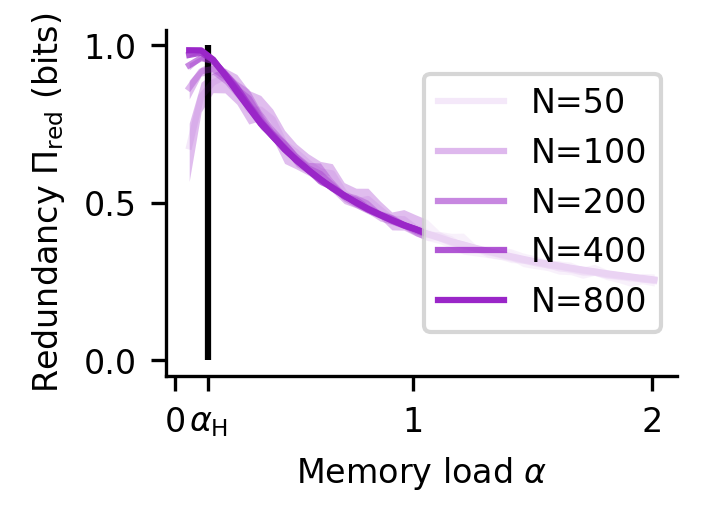

In [6]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=colors)
plotting.standard_look(ax)

ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Redundancy $\Pi_\mathrm{red}$ (bits)')
ax.vlines(alpha_h, 0, 1, color='k')
ax.set_xticks([0, 1, 2, alpha_h], [0, 1, 2, r'$\alpha_\mathrm{H}$'])
ax.set_yticks([0, 0.5, 1])

for y, n in zip(redundancy, neuron_labels):
    plotting.plot_mean_and_area(ax, x, y, mean_ax=0, quantile=0.9, median=True, label=f'N={n}')

ax.legend(loc='right')
# fig.savefig(f"{plot_path}/hebb_scaling.svg", bbox_inches="tight")
plt.show()